In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("fraud_detection_dashboard_data.csv")

In [6]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V26,V27,V28,Amount,Class,Hour,Amount_log,Is_night,Predicted_Class,Fraud_Probability
Time,1.000000,0.121501,-0.010010,-0.409262,-0.110496,0.169351,-0.069177,0.080850,-0.039203,-0.010589,...,-0.047847,-0.007281,-0.009614,-0.021443,-0.016360,0.412918,-0.030835,-0.076707,-0.010595,-0.025600
V1,0.121501,1.000000,0.024479,0.014024,-0.013833,-0.000260,0.005371,0.031038,-0.008211,0.000346,...,-0.003376,-0.009217,-0.054284,-0.229877,-0.110949,-0.005075,-0.106173,-0.017510,-0.050382,-0.052018
V2,-0.010010,0.024479,1.000000,-0.013234,0.005257,-0.034757,0.014649,0.005406,-0.000920,-0.005181,...,0.006377,0.035925,-0.024529,-0.519233,0.101267,0.005962,-0.447006,0.083269,0.119625,0.154767
V3,-0.409262,0.014024,-0.013234,1.000000,0.003012,0.021980,0.006726,0.015119,-0.013904,-0.004174,...,0.013297,-0.004990,-0.011924,-0.200118,-0.203281,-0.010805,-0.030317,0.049380,-0.015445,0.024969
V4,-0.110496,-0.013833,0.005257,0.003012,1.000000,0.011694,0.006393,-0.005916,-0.013771,-0.002596,...,0.007315,0.006931,-0.001700,0.088085,0.117778,-0.040213,-0.010566,0.026690,0.267089,0.341687


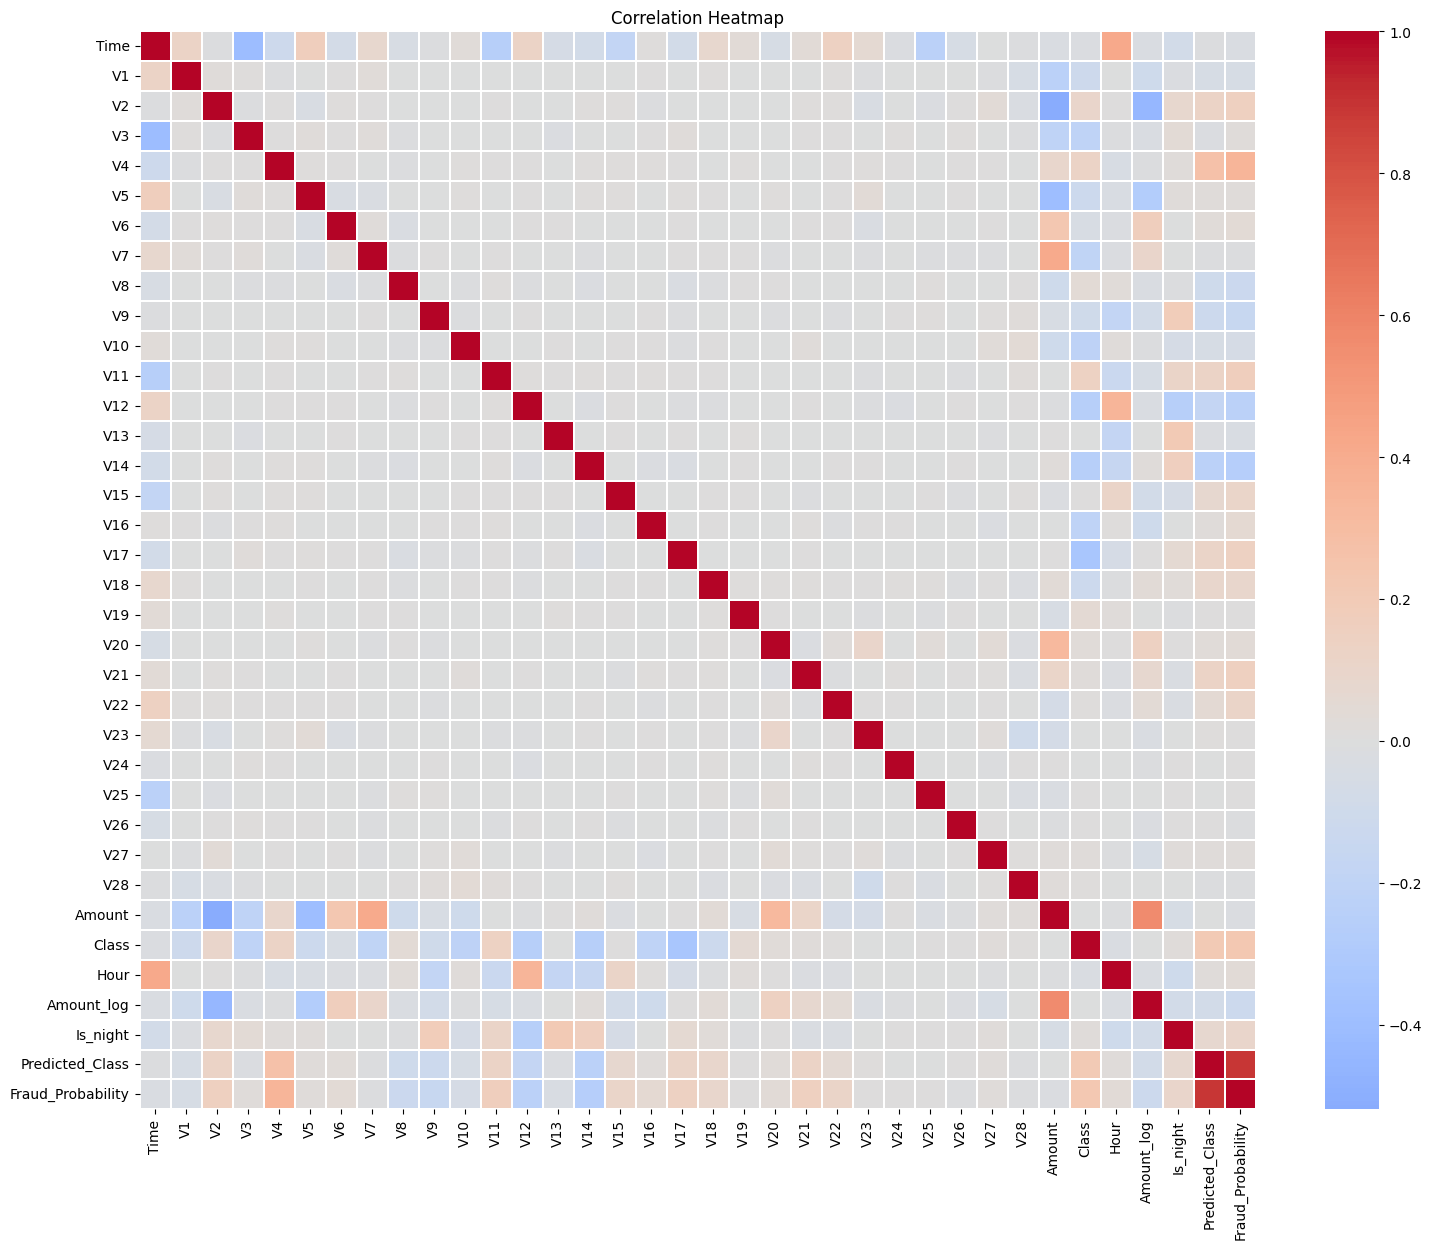

In [7]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap")
plt.show()

In [8]:
fraud_corr = corr_matrix["Class"].sort_values(ascending=False)

fraud_corr

,Class
Class,1.000000
Fraud_Probability,0.227585
Predicted_Class,0.207878
V11,0.137595
V4,0.117778
V2,0.101267
V19,0.051279
V8,0.047929
V20,0.029910
V21,0.026245


In [9]:
top_positive = fraud_corr.drop("Class").head(10)

print("Top Positive Correlations with Fraud:")
print(top_positive)

Top Positive Correlations with Fraud:
Fraud_Probability    0.227585
Predicted_Class      0.207878
V11                  0.137595
V4                   0.117778
V2                   0.101267
V19                  0.051279
V8                   0.047929
V20                  0.029910
V21                  0.026245
V27                  0.025747
Name: Class, dtype: float64


In [10]:
top_negative = fraud_corr.tail(10)

print("Top Negative Correlations with Fraud:")
print(top_negative)

Top Negative Correlations with Fraud:
V1    -0.110949
V5    -0.119833
V18   -0.121421
V7    -0.198666
V16   -0.202521
V3    -0.203281
V10   -0.211482
V12   -0.246671
V14   -0.254896
V17   -0.337094
Name: Class, dtype: float64


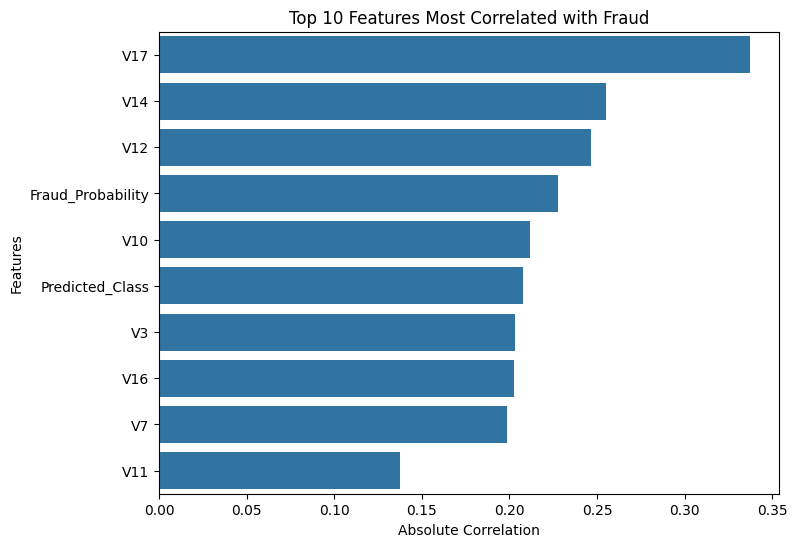

In [11]:
top_features = fraud_corr.drop("Class").abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top 10 Features Most Correlated with Fraud")
plt.xlabel("Absolute Correlation")
plt.ylabel("Features")

plt.show()